**LSA8 Phase Pattern Extractor - Morning**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 5: LSA8 PHASE PATTERN EXTRACTOR
# ============================================================
# Purpose:
# - Read LSA8 signal-state JSON files
# - Select one representative scenario
# - Extract K1, K2, K3, K4, K5, K6 states second by second
# - Compress consecutive identical signal-state combinations
# - Create phase block table for static SUMO approximation
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA8_fb0a2f57-9872-49df-9323-f392b700d8ba"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_NAME = "weekday_morning"
TARGET_DATE = "2026-03-10"
WINDOW_START = "08:00:00"
WINDOW_END = "09:00:00"

OUT_CSV = OUT_DIR / f"LSA8_phase_blocks_{SCENARIO_NAME}.csv"
OUT_XLSX = OUT_DIR / f"LSA8_phase_blocks_{SCENARIO_NAME}.xlsx"

# ============================================================
# SIGNAL GROUP MAPPING
# ============================================================
# JSON signal IDs:
# K1 = 1
# K2 = 2
# K3 = 3
# K4 = 4
# K5 = 5
# K6 = 6
# ============================================================

SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
    "K5": 5,
    "K6": 6,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5", "K6"]

# ============================================================
# PARSE SIGNAL DATA
# ============================================================

rows = []

for json_path in sorted(SIGNAL_DIR.glob("*.json")):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_utc = pd.to_datetime(data["start"])

    for value in data.get("values", []):
        timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
        timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

        date_local = str(timestamp_local.date())
        time_local = timestamp_local.time()

        if date_local != TARGET_DATE:
            continue

        start_t = pd.to_datetime(WINDOW_START).time()
        end_t = pd.to_datetime(WINDOW_END).time()

        if not (start_t <= time_local < end_t):
            continue

        sig_states = {
            item["id"]: item["sgState"]
            for item in value.get("sigState", [])
        }

        node_info = value.get("nodes", [{}])[0]

        row = {
            "timestamp_local": timestamp_local,
            "date": date_local,
            "time": time_local,
            "program": node_info.get("program"),
            "stage": node_info.get("stage"),
            "cycCnt": node_info.get("cycCnt"),
            "stgCnt": node_info.get("stgCnt"),
            "stgTran": node_info.get("stgTran"),
        }

        for group_name, signal_id in SIGNAL_GROUPS.items():
            row[group_name] = sig_states.get(signal_id)

        rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No signal data found for selected date and time window.")

df = df.sort_values("timestamp_local").reset_index(drop=True)

# ============================================================
# CREATE SIGNAL PATTERN K1-K2-K3-K4-K5-K6
# ============================================================

for col in GROUP_COLUMNS:
    if df[col].isna().any():
        missing_count = df[col].isna().sum()
        raise ValueError(f"{col} has {missing_count} missing values. Check signal_id mapping.")

    df[col] = df[col].astype(int)

df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)

# ============================================================
# COMPRESS CONSECUTIVE IDENTICAL PATTERNS INTO PHASE BLOCKS
# ============================================================

df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

phase_blocks = (
    df.groupby("block_id")
    .agg(
        start_time=("timestamp_local", "first"),
        end_time=("timestamp_local", "last"),
        date=("date", "first"),
        K1=("K1", "first"),
        K2=("K2", "first"),
        K3=("K3", "first"),
        K4=("K4", "first"),
        K5=("K5", "first"),
        K6=("K6", "first"),
        pattern=("pattern", "first"),
        stage=("stage", "first"),
        program=("program", "first"),
        n_seconds=("pattern", "count"),
    )
    .reset_index()
)

phase_blocks["duration_s"] = phase_blocks["n_seconds"]

phase_blocks_excel = phase_blocks.copy()
phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

# ============================================================
# PATTERN SUMMARY
# ============================================================

pattern_summary = (
    phase_blocks
    .groupby(["pattern"] + GROUP_COLUMNS)
    .agg(
        occurrences=("block_id", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
    )
    .reset_index()
    .sort_values("total_duration_s", ascending=False)
)

# ============================================================
# SAVE OUTPUTS
# ============================================================

phase_blocks_excel.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

df_excel = df.copy()
df_excel["timestamp_local"] = df_excel["timestamp_local"].astype(str)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    phase_blocks_excel.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    df_excel.to_excel(writer, sheet_name="Secondwise_K1_K6", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nTop recurring patterns:")
print(pattern_summary.head(20))

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\LSA8_phase_blocks_weekday_morning.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\LSA8_phase_blocks_weekday_morning.xlsx

Top recurring patterns:
        pattern  K1  K2  K3  K4  K5  K6  occurrences  total_duration_s  \
16  4-2-4-2-2-2   4   2   4   2   2   2           40              1263   
9   2-4-2-2-4-2   2   4   2   2   4   2           40               918   
5   2-2-4-4-2-2   2   2   4   4   2   2           31               288   
13  4-2-2-2-2-4   4   2   2   2   2   4           26               236   
0   2-2-2-2-2-2   2   2   2   2   2   2           55               165   
7   2-3-2-2-3-2   2   3   2   2   3   2           40               111   
3   2-2-4-2-2-2   2   2   4   2   2   2           31                93   
4   2-2-4-3-2-2   2   2   4   3   2   2           31                93   
11  3-2-2-2-2-4   3   2   2   2   2   4           25       

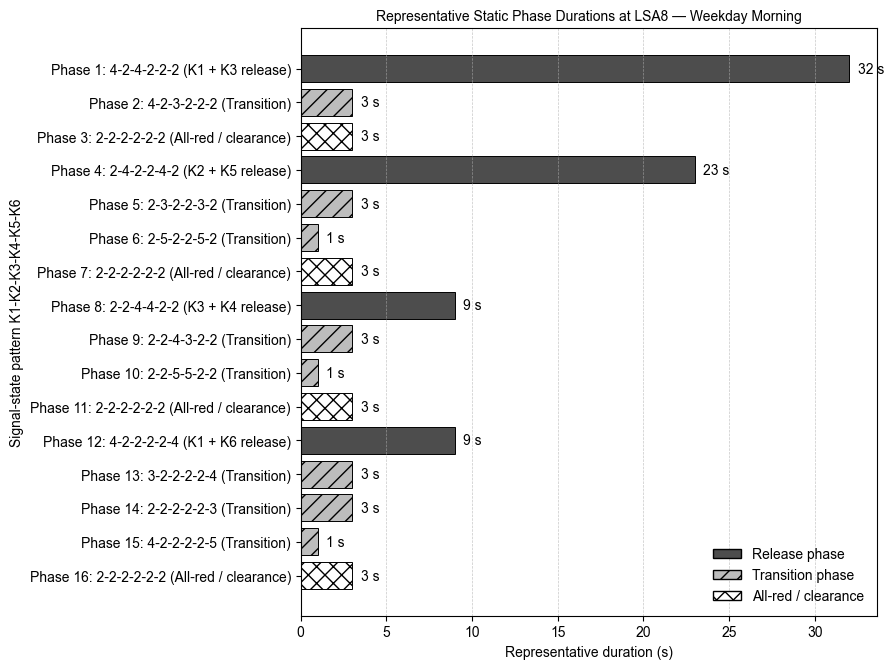

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures\LSA8_representative_phase_durations_weekday_morning_accessible.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures\LSA8_representative_phase_durations_weekday_morning_accessible.svg

Representative static phase table:
    phase      pattern  phase_type          description  \
0       1  4-2-4-2-2-2     Release      K1 + K3 release   
1       2  4-2-3-2-2-2  Transition           Transition   
2       3  2-2-2-2-2-2   Clearance  All-red / clearance   
3       4  2-4-2-2-4-2     Release      K2 + K5 release   
4       5  2-3-2-2-3-2  Transition           Transition   
5       6  2-5-2-2-5-2  Transition           Transition   
6       7  2-2-2-2-2-2   Clearance  All-red / clearance   
7       8  2-2-4-4-2-2     Release      K3 + K4 release   
8       9  2-2-4-3-2-2  Transition           Transition   
9      10  2-2-5-5-2-2  Transition           Transition   
10     11 

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 5B: LSA8 REPRESENTATIVE PHASE DURATION FIGURE
# ============================================================
# Purpose:
# - Read LSA8 phase block output
# - Create a thesis-style horizontal bar chart
# - Distinguish release, transition, and clearance phases
# - Avoid red/green color dependency
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation"
)

IN_XLSX = BASE_DIR / "LSA8_phase_blocks_weekday_morning.xlsx"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "LSA8_representative_phase_durations_weekday_morning_accessible.png"
OUT_SVG = OUT_DIR / "LSA8_representative_phase_durations_weekday_morning_accessible.svg"

# ============================================================
# LOAD DATA
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE FOR LSA8
# ============================================================
# Pattern order: K1-K2-K3-K4-K5-K6
#
# Main observed release patterns:
# 4-2-4-2-2-2 = K1 + K3 release
# 2-4-2-2-4-2 = K2 + K5 release
# 2-2-4-4-2-2 = K3 + K4 release
# 4-2-2-2-2-4 = K1 + K6 release
# ============================================================

representative_rows = [
    {
        "phase": 1,
        "pattern": "4-2-4-2-2-2",
        "phase_type": "Release",
        "description": "K1 + K3 release"
    },
    {
        "phase": 2,
        "pattern": "4-2-3-2-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 3,
        "pattern": "2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 4,
        "pattern": "2-4-2-2-4-2",
        "phase_type": "Release",
        "description": "K2 + K5 release"
    },
    {
        "phase": 5,
        "pattern": "2-3-2-2-3-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 6,
        "pattern": "2-5-2-2-5-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 7,
        "pattern": "2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 8,
        "pattern": "2-2-4-4-2-2",
        "phase_type": "Release",
        "description": "K3 + K4 release"
    },
    {
        "phase": 9,
        "pattern": "2-2-4-3-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 10,
        "pattern": "2-2-5-5-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 11,
        "pattern": "2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 12,
        "pattern": "4-2-2-2-2-4",
        "phase_type": "Release",
        "description": "K1 + K6 release"
    },
    {
        "phase": 13,
        "pattern": "3-2-2-2-2-4",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 14,
        "pattern": "2-2-2-2-2-3",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 15,
        "pattern": "4-2-2-2-2-5",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 16,
        "pattern": "2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
]

df = pd.DataFrame(representative_rows)
df["representative_duration_s"] = df["pattern"].map(duration_lookup)

missing = df[df["representative_duration_s"].isna()]
if not missing.empty:
    raise ValueError(
        "Some representative patterns were not found in Pattern_Summary:\n"
        + str(missing[["phase", "pattern", "description"]])
    )

df["representative_duration_s"] = df["representative_duration_s"].astype(int)

# ============================================================
# ACCESSIBLE STYLE
# ============================================================

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase"
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase"
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance"
    },
}

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9.0, 6.8))

y_labels = [
    f"Phase {row.phase}: {row.pattern} ({row.description})"
    for _, row in df.iterrows()
]

for i, row in df.iterrows():
    style = STYLE[row["phase_type"]]

    ax.barh(
        y_labels[i],
        row["representative_duration_s"],
        color=style["color"],
        edgecolor="black",
        linewidth=0.7,
        hatch=style["hatch"]
    )

ax.set_title("Representative Static Phase Durations at LSA8 — Weekday Morning")
ax.set_xlabel("Representative duration (s)")
ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5-K6")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

for i, row in df.iterrows():
    ax.text(
        row["representative_duration_s"] + 0.5,
        i,
        f"{row['representative_duration_s']} s",
        va="center"
    )

ax.invert_yaxis()

legend_handles = []
legend_labels = []

for phase_type, style in STYLE.items():
    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"]
    )
    legend_handles.append(handle)
    legend_labels.append(style["label"])

ax.legend(
    legend_handles,
    legend_labels,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_SVG, bbox_inches="tight")
plt.show()

print("Saved:")
print(OUT_PNG)
print(OUT_SVG)

print("\nRepresentative static phase table:")
print(df[[
    "phase",
    "pattern",
    "phase_type",
    "description",
    "representative_duration_s"
]])

print("\nApproximate representative cycle length:")
print(df["representative_duration_s"].sum(), "seconds")

In [3]:
from pathlib import Path
import pandas as pd
from xml.dom import minidom
import xml.etree.ElementTree as ET

# ============================================================
# CODE 6: LSA8 STATIC SUMO TLS PROGRAM GENERATOR
# ============================================================
# Purpose:
# - Read representative phase pattern durations for LSA8
# - Convert K1-K2-K3-K4-K5-K6 signal-state patterns into SUMO TLS states
# - Use NetEdit TLS link index mapping
# - Create a static SUMO additional file for LSA8
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation"
)

IN_XLSX = BASE_DIR / "LSA8_phase_blocks_weekday_morning.xlsx"

OUT_XML = BASE_DIR / "LSA8_static_tls_weekday_morning.add.xml"
OUT_PHASE_TABLE_CSV = BASE_DIR / "LSA8_static_tls_weekday_morning_phase_table.csv"

# Replace with exact SUMO TLS id from NetEdit if different
TLS_ID = "tls_9873"

PROGRAM_ID = "derived_weekday_morning"

# ============================================================
# SUMO LINK INDEX TO SIGNAL GROUP MAPPING
# ============================================================
# index 0 -> East straight                  -> K3
# index 1 -> East left turn                 -> K4
# index 2 -> South straight/right           -> K5
# index 3 -> South left                     -> K5
# index 4 -> West straight/left             -> K1
# index 5 -> West left                      -> K6
# index 6 -> North/South? straight/right    -> K2
# index 7 -> North/South? left              -> K2
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K3",
    1: "K4",
    2: "K5",
    3: "K5",
    4: "K1",
    5: "K6",
    6: "K2",
    7: "K2",
}

# ============================================================
# SIGNAL STATE TO SUMO TLS CHARACTER
# ============================================================

def sgstate_to_sumo_char(sg_state):
    """
    Converts SI PL sgState to SUMO TLS character.

    4    -> G : protected green / release
    3,5  -> y : transition / yellow-like state
    2    -> r : red / blocked
    """
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    """
    Converts pattern like '4-2-4-2-2-2' for K1-K2-K3-K4-K5-K6
    into SUMO TLS state string according to LINK_INDEX_TO_GROUP.
    """
    k1, k2, k3, k4, k5, k6 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k5),
        "K6": sgstate_to_sumo_char(k6),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )

# ============================================================
# LOAD REPRESENTATIVE PATTERN SUMMARY
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE
# ============================================================
# Pattern order: K1-K2-K3-K4-K5-K6
# Based on extracted weekday morning recurring phase structure.
# ============================================================

representative_phases = [
    {
        "phase": 1,
        "pattern": "4-2-4-2-2-2",
        "description": "K1 + K3 release",
    },
    {
        "phase": 2,
        "pattern": "4-2-3-2-2-2",
        "description": "Transition",
    },
    {
        "phase": 3,
        "pattern": "2-2-2-2-2-2",
        "description": "All-red / clearance",
    },
    {
        "phase": 4,
        "pattern": "2-4-2-2-4-2",
        "description": "K2 + K5 release",
    },
    {
        "phase": 5,
        "pattern": "2-3-2-2-3-2",
        "description": "Transition",
    },
    {
        "phase": 6,
        "pattern": "2-5-2-2-5-2",
        "description": "Transition",
    },
    {
        "phase": 7,
        "pattern": "2-2-2-2-2-2",
        "description": "All-red / clearance",
    },
    {
        "phase": 8,
        "pattern": "2-2-4-4-2-2",
        "description": "K3 + K4 release",
    },
    {
        "phase": 9,
        "pattern": "2-2-4-3-2-2",
        "description": "Transition",
    },
    {
        "phase": 10,
        "pattern": "2-2-5-5-2-2",
        "description": "Transition",
    },
    {
        "phase": 11,
        "pattern": "2-2-2-2-2-2",
        "description": "All-red / clearance",
    },
    {
        "phase": 12,
        "pattern": "4-2-2-2-2-4",
        "description": "K1 + K6 release",
    },
    {
        "phase": 13,
        "pattern": "3-2-2-2-2-4",
        "description": "Transition",
    },
    {
        "phase": 14,
        "pattern": "2-2-2-2-2-3",
        "description": "Transition",
    },
    {
        "phase": 15,
        "pattern": "4-2-2-2-2-5",
        "description": "Transition",
    },
    {
        "phase": 16,
        "pattern": "2-2-2-2-2-2",
        "description": "All-red / clearance",
    },
]

# ============================================================
# CREATE PHASE TABLE
# ============================================================

phase_rows = []

for phase in representative_phases:
    pattern = phase["pattern"]

    if pattern not in duration_lookup:
        raise ValueError(f"Pattern {pattern} not found in Pattern_Summary.")

    duration = duration_lookup[pattern]
    sumo_state = pattern_to_sumo_state(pattern)

    k1, k2, k3, k4, k5, k6 = [int(x) for x in pattern.split("-")]

    phase_rows.append({
        "phase": phase["phase"],
        "pattern_K1_K2_K3_K4_K5_K6": pattern,
        "K1": k1,
        "K2": k2,
        "K3": k3,
        "K4": k4,
        "K5": k5,
        "K6": k6,
        "duration_s": duration,
        "sumo_state": sumo_state,
        "description": phase["description"],
    })

phase_table = pd.DataFrame(phase_rows)

# ============================================================
# CREATE SUMO TLS XML
# ============================================================

additional = ET.Element("additional")

tl_logic = ET.SubElement(
    additional,
    "tlLogic",
    {
        "id": TLS_ID,
        "type": "static",
        "programID": PROGRAM_ID,
        "offset": "0",
    }
)

for _, row in phase_table.iterrows():
    ET.SubElement(
        tl_logic,
        "phase",
        {
            "duration": str(int(row["duration_s"])),
            "state": row["sumo_state"],
        }
    )

rough_string = ET.tostring(additional, encoding="utf-8")
parsed = minidom.parseString(rough_string)
pretty_xml = parsed.toprettyxml(indent="    ")

with open(OUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

phase_table.to_csv(OUT_PHASE_TABLE_CSV, index=False, encoding="utf-8-sig")

# ============================================================
# PRINT RESULTS
# ============================================================

print("Saved SUMO TLS additional file:")
print(OUT_XML)

print("\nSaved phase table:")
print(OUT_PHASE_TABLE_CSV)

print("\nGenerated static phase table:")
print(phase_table)

print("\nSUMO state string length:")
print(len(phase_table.iloc[0]["sumo_state"]))

print("\nApproximate static cycle length:")
print(phase_table["duration_s"].sum(), "seconds")

Saved SUMO TLS additional file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\LSA8_static_tls_weekday_morning.add.xml

Saved phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\LSA8_static_tls_weekday_morning_phase_table.csv

Generated static phase table:
    phase pattern_K1_K2_K3_K4_K5_K6  K1  K2  K3  K4  K5  K6  duration_s  \
0       1               4-2-4-2-2-2   4   2   4   2   2   2          32   
1       2               4-2-3-2-2-2   4   2   3   2   2   2           3   
2       3               2-2-2-2-2-2   2   2   2   2   2   2           3   
3       4               2-4-2-2-4-2   2   4   2   2   4   2          23   
4       5               2-3-2-2-3-2   2   3   2   2   3   2           3   
5       6               2-5-2-2-5-2   2   5   2   2   5   2           1   
6       7               2-2-2-2-2-2   2   2   2   2   2   2           3   
7       8               2-2-4-4-2-2   2   2   4   4   2   2           9   
8     

extract phase patterns for all 4 representative scenarios

create one Excel with phase blocks + summaries

create one static TLS XML per scenario

create one phase-duration graph per scenario


Found signal JSON files: 320
Parsed rows: 576655

Processing scenario: weekday_morning

Available patterns:
        pattern  occurrences  total_duration_s  mean_duration_s
16  4-2-4-2-2-2           40              1263        31.575000
9   2-4-2-2-4-2           40               918        22.950000
5   2-2-4-4-2-2           31               288         9.290323
13  4-2-2-2-2-4           26               236         9.076923
0   2-2-2-2-2-2           55               165         3.000000
7   2-3-2-2-3-2           40               111         2.775000
3   2-2-4-2-2-2           31                93         3.000000
4   2-2-4-3-2-2           31                93         3.000000
11  3-2-2-2-2-4           25                75         3.000000
1   2-2-2-2-2-3           25                75         3.000000
15  4-2-3-2-2-2           25                75         3.000000
12  3-2-3-2-2-2           15                45         3.000000
10  2-5-2-2-5-2           40                40         1.000

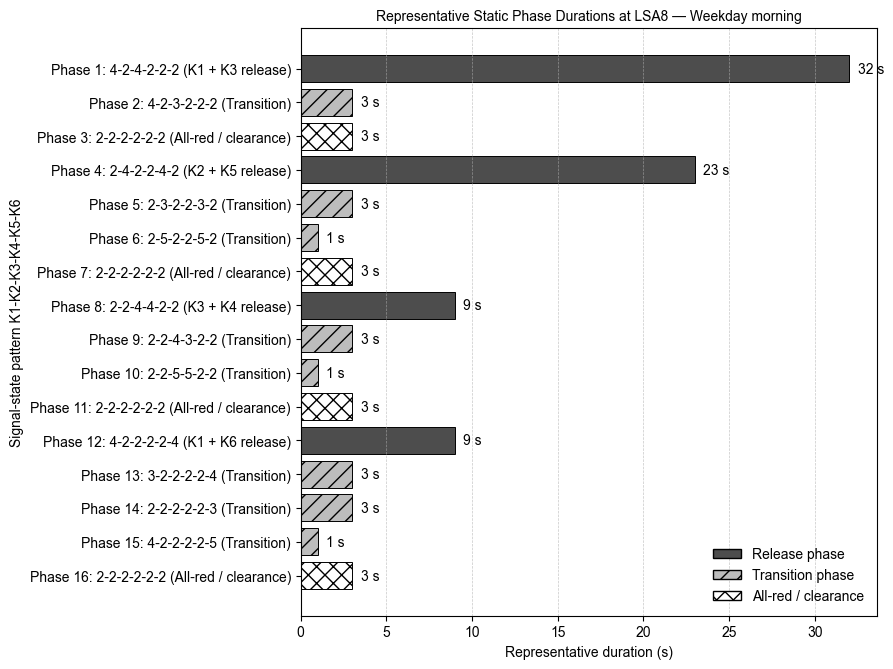

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures\LSA8_representative_phase_durations_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures\LSA8_representative_phase_durations_weekday_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\static_tls_programs\LSA8_static_tls_weekday_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\static_tls_programs\LSA8_static_tls_weekday_morning_phase_table.csv
SUMO state string length: 8
Approximate static cycle length: 103 s

Processing scenario: weekday_evening
No data found for weekday_evening. Skipping.

Processing scenario: weekend_morning
No data found for weekend_morning. Skipping.

Processing scenario: weekend_evening
No data found for weekend_evening. Skipping.

DONE
Saved combined Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\sa

In [4]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from xml.dom import minidom

# ============================================================
# CODE 7: LSA8 STATIC TLS PROGRAMS + PHASE GRAPHS FOR ALL SCENARIOS
# ============================================================
# Purpose:
# - Extract phase patterns for all representative scenarios
# - Build representative static phase tables
# - Generate SUMO static TLS additional files
# - Create phase duration figures for each scenario
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA8_fb0a2f57-9872-49df-9323-f392b700d8ba"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TLS_DIR = OUT_DIR / "static_tls_programs"
TLS_DIR.mkdir(parents=True, exist_ok=True)

# Replace with exact NetEdit TLS id if different
TLS_ID = "tls_9873"

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-03-10",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekday morning",
    },
    "weekday_evening": {
        "date": "2026-03-23",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekday evening",
    },
    "weekend_morning": {
        "date": "2026-03-14",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekend morning",
    },
    "weekend_evening": {
        "date": "2026-03-22",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekend evening",
    },
}

# JSON signal IDs
SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
    "K5": 5,
    "K6": 6,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5", "K6"]

# ============================================================
# SUMO LINK INDEX TO SIGNAL GROUP MAPPING
# ============================================================
# index 0 -> East straight               -> K3
# index 1 -> East left turn              -> K4
# index 2 -> South straight/right        -> K5
# index 3 -> South left                  -> K5
# index 4 -> West straight/left          -> K1
# index 5 -> West left                   -> K6
# index 6 -> opposite approach straight/right -> K2
# index 7 -> opposite approach left           -> K2
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K3",
    1: "K4",
    2: "K5",
    3: "K5",
    4: "K1",
    5: "K6",
    6: "K2",
    7: "K2",
}

# Pattern order: K1-K2-K3-K4-K5-K6
REPRESENTATIVE_PHASE_SEQUENCE = [
    {"phase": 1,  "pattern": "4-2-4-2-2-2", "phase_type": "Release",    "description": "K1 + K3 release"},
    {"phase": 2,  "pattern": "4-2-3-2-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 3,  "pattern": "2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 4,  "pattern": "2-4-2-2-4-2", "phase_type": "Release",    "description": "K2 + K5 release"},
    {"phase": 5,  "pattern": "2-3-2-2-3-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 6,  "pattern": "2-5-2-2-5-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 7,  "pattern": "2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 8,  "pattern": "2-2-4-4-2-2", "phase_type": "Release",    "description": "K3 + K4 release"},
    {"phase": 9,  "pattern": "2-2-4-3-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 10, "pattern": "2-2-5-5-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 11, "pattern": "2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 12, "pattern": "4-2-2-2-2-4", "phase_type": "Release",    "description": "K1 + K6 release"},
    {"phase": 13, "pattern": "3-2-2-2-2-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 14, "pattern": "2-2-2-2-2-3", "phase_type": "Transition", "description": "Transition"},
    {"phase": 15, "pattern": "4-2-2-2-2-5", "phase_type": "Transition", "description": "Transition"},
    {"phase": 16, "pattern": "2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},
]

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase",
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase",
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance",
    },
}

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def sgstate_to_sumo_char(sg_state):
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    k1, k2, k3, k4, k5, k6 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k5),
        "K6": sgstate_to_sumo_char(k6),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )


def save_sumo_tls_xml(phase_table, out_xml, program_id):
    additional = ET.Element("additional")

    tl_logic = ET.SubElement(
        additional,
        "tlLogic",
        {
            "id": TLS_ID,
            "type": "static",
            "programID": program_id,
            "offset": "0",
        }
    )

    for _, row in phase_table.iterrows():
        ET.SubElement(
            tl_logic,
            "phase",
            {
                "duration": str(int(row["duration_s"])),
                "state": row["sumo_state"],
            }
        )

    rough_string = ET.tostring(additional, encoding="utf-8")
    parsed = minidom.parseString(rough_string)
    pretty_xml = parsed.toprettyxml(indent="    ")

    with open(out_xml, "w", encoding="utf-8") as f:
        f.write(pretty_xml)


def plot_phase_durations(phase_table, scenario_name, scenario_label):
    out_png = FIG_DIR / f"LSA8_representative_phase_durations_{scenario_name}.png"
    out_svg = FIG_DIR / f"LSA8_representative_phase_durations_{scenario_name}.svg"

    fig, ax = plt.subplots(figsize=(9.0, 6.8))

    y_labels = [
        f"Phase {row.phase}: {row.pattern_K1_K2_K3_K4_K5_K6} ({row.description})"
        for _, row in phase_table.iterrows()
    ]

    for i, row in phase_table.iterrows():
        style = STYLE[row["phase_type"]]

        ax.barh(
            y_labels[i],
            row["duration_s"],
            color=style["color"],
            edgecolor="black",
            linewidth=0.7,
            hatch=style["hatch"]
        )

        ax.text(
            row["duration_s"] + 0.5,
            i,
            f"{int(row['duration_s'])} s",
            va="center"
        )

    ax.set_title(f"Representative Static Phase Durations at LSA8 — {scenario_label}")
    ax.set_xlabel("Representative duration (s)")
    ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5-K6")
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()

    legend_handles = []
    legend_labels = []

    for _, style in STYLE.items():
        handle = plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=style["color"],
            edgecolor="black",
            hatch=style["hatch"]
        )
        legend_handles.append(handle)
        legend_labels.append(style["label"])

    ax.legend(
        legend_handles,
        legend_labels,
        frameon=False,
        loc="lower right"
    )

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved figure:")
    print(out_png)
    print(out_svg)


# ============================================================
# PARSE ALL SIGNAL FILES ONCE
# ============================================================

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            row = {
                "timestamp_local": timestamp_local,
                "date": str(timestamp_local.date()),
                "time": timestamp_local.time(),
                "program": node_info.get("program"),
                "stage": node_info.get("stage"),
                "cycCnt": node_info.get("cycCnt"),
                "stgCnt": node_info.get("stgCnt"),
                "stgTran": node_info.get("stgTran"),
            }

            for group_name, signal_id in SIGNAL_GROUPS.items():
                row[group_name] = sig_states.get(signal_id)

            rows.append(row)

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise ValueError("No signal data parsed.")

print("Parsed rows:", len(df_all))

# ============================================================
# PROCESS EACH SCENARIO
# ============================================================

all_phase_blocks = []
all_pattern_summaries = []
all_static_phase_tables = []

for scenario_name, scenario in SCENARIOS.items():

    print("\n" + "=" * 70)
    print(f"Processing scenario: {scenario_name}")
    print("=" * 70)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    df = df_all[
        (df_all["date"] == scenario["date"]) &
        (df_all["time"] >= start_t) &
        (df_all["time"] < end_t)
    ].copy()

    if df.empty:
        print(f"No data found for {scenario_name}. Skipping.")
        continue

    df = df.sort_values("timestamp_local").reset_index(drop=True)

    for col in GROUP_COLUMNS:
        if df[col].isna().any():
            missing_count = df[col].isna().sum()
            raise ValueError(f"{col} has {missing_count} missing values. Check signal_id mapping.")
        df[col] = df[col].astype(int)

    df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)

    df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

    phase_blocks = (
        df.groupby("block_id")
        .agg(
            start_time=("timestamp_local", "first"),
            end_time=("timestamp_local", "last"),
            date=("date", "first"),
            K1=("K1", "first"),
            K2=("K2", "first"),
            K3=("K3", "first"),
            K4=("K4", "first"),
            K5=("K5", "first"),
            K6=("K6", "first"),
            pattern=("pattern", "first"),
            stage=("stage", "first"),
            program=("program", "first"),
            n_seconds=("pattern", "count"),
        )
        .reset_index()
    )

    phase_blocks["duration_s"] = phase_blocks["n_seconds"]
    phase_blocks["scenario"] = scenario_name
    phase_blocks["window_start"] = scenario["start"]
    phase_blocks["window_end"] = scenario["end"]

    pattern_summary = (
        phase_blocks
        .groupby(["scenario", "pattern"] + GROUP_COLUMNS)
        .agg(
            occurrences=("block_id", "count"),
            total_duration_s=("duration_s", "sum"),
            mean_duration_s=("duration_s", "mean"),
            median_duration_s=("duration_s", "median"),
            min_duration_s=("duration_s", "min"),
            max_duration_s=("duration_s", "max"),
        )
        .reset_index()
        .sort_values("total_duration_s", ascending=False)
    )

    duration_lookup = {
        str(row["pattern"]): int(round(row["mean_duration_s"]))
        for _, row in pattern_summary.iterrows()
    }

    print("\nAvailable patterns:")
    print(pattern_summary[["pattern", "occurrences", "total_duration_s", "mean_duration_s"]].head(20))

    static_rows = []

    for phase in REPRESENTATIVE_PHASE_SEQUENCE:
        pattern = phase["pattern"]

        if pattern not in duration_lookup:
            raise ValueError(
                f"Pattern {pattern} not found for {scenario_name}. "
                f"Available patterns are: {list(duration_lookup.keys())}"
            )

        duration = duration_lookup[pattern]
        sumo_state = pattern_to_sumo_state(pattern)

        k1, k2, k3, k4, k5, k6 = [int(x) for x in pattern.split("-")]

        static_rows.append({
            "scenario": scenario_name,
            "phase": phase["phase"],
            "pattern_K1_K2_K3_K4_K5_K6": pattern,
            "K1": k1,
            "K2": k2,
            "K3": k3,
            "K4": k4,
            "K5": k5,
            "K6": k6,
            "duration_s": duration,
            "sumo_state": sumo_state,
            "phase_type": phase["phase_type"],
            "description": phase["description"],
        })

    static_phase_table = pd.DataFrame(static_rows)

    program_id = f"derived_{scenario_name}"

    out_xml = TLS_DIR / f"LSA8_static_tls_{scenario_name}.add.xml"
    out_csv = TLS_DIR / f"LSA8_static_tls_{scenario_name}_phase_table.csv"

    save_sumo_tls_xml(static_phase_table, out_xml, program_id)
    static_phase_table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    plot_phase_durations(static_phase_table, scenario_name, scenario["label"])

    print("\nSaved SUMO TLS XML:")
    print(out_xml)

    print("Saved static phase table:")
    print(out_csv)

    print("SUMO state string length:", len(static_phase_table.iloc[0]["sumo_state"]))
    print("Approximate static cycle length:", static_phase_table["duration_s"].sum(), "s")

    phase_blocks_excel = phase_blocks.copy()
    phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
    phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

    all_phase_blocks.append(phase_blocks_excel)
    all_pattern_summaries.append(pattern_summary)
    all_static_phase_tables.append(static_phase_table)

# ============================================================
# SAVE COMBINED EXCEL
# ============================================================

combined_phase_blocks = pd.concat(all_phase_blocks, ignore_index=True)
combined_pattern_summary = pd.concat(all_pattern_summaries, ignore_index=True)
combined_static_phase_table = pd.concat(all_static_phase_tables, ignore_index=True)

OUT_XLSX = OUT_DIR / "LSA8_all_scenarios_phase_patterns_and_static_tls.xlsx"

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    combined_phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    combined_pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    combined_static_phase_table.to_excel(writer, sheet_name="Static_TLS_Phase_Table", index=False)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("Saved combined Excel:")
print(OUT_XLSX)

print("\nSaved TLS XML files in:")
print(TLS_DIR)

print("\nSaved figures in:")
print(FIG_DIR)

print("\nStatic phase table preview:")
print(combined_static_phase_table)

print("\nCycle lengths by scenario:")
print(
    combined_static_phase_table
    .groupby("scenario")["duration_s"]
    .sum()
    .reset_index(name="approx_static_cycle_length_s")
)

**For LSA8, no detector count data was available. Therefore, the analysis was limited to the derivation of an approximate static signal program from the signal-state process data. The signal-state data was parsed for the available representative period and compressed into recurring phase blocks based on the signal groups K1–K6.**

**The extracted weekday morning pattern showed four main release phases. The first major release phase served signal groups K1 and K3, followed by a second release phase for K2 and K5. Two shorter release phases were also identified for K3/K4 and K1/K6. Between these release phases, short intermediate states were observed and interpreted as transition or clearance intervals.**

**For the SUMO implementation, the original release durations were preserved, while short consecutive transition states were aggregated into longer transition intervals. This simplification did not change the total cycle length. The resulting static signal program has an approximate cycle length of 103 seconds and provides a reproducible approximation of the observed signal control logic for LSA8.**

FileNotFoundError: File not found: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures\LSA8_representative_phase_durations_weekday_evening.png

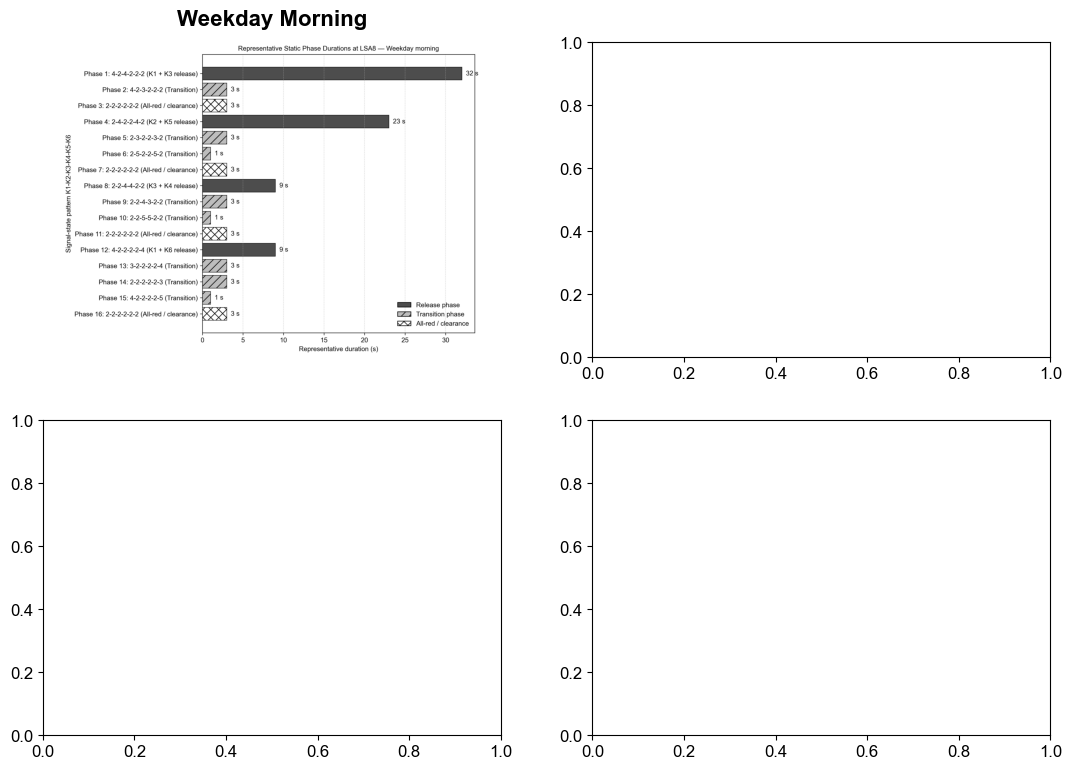

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA8_saturation\figures"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

prefix = "LSA8_representative_phase_durations"

out_file = BASE_DIR / "LSA8_representative_phase_durations_combined.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{prefix}_{scenario}.png"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")